In [2]:
print("Installing required packages...")
!pip install -q pandas numpy matplotlib seaborn plotly
print("  packages installed !")

Installing required packages...
  packages installed !


In [63]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")



In [64]:
import os

folders = ["data/raw", "data/cleaned", "data/final", "visualizations", "reports"]
for f in folders:
    os.makedirs(f, exist_ok=True)


In [141]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df.to_csv("data/raw/telco_churn_raw.csv", index=False)


print(f"Dataset shape: {df.shape}")
print(f" Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Dataset shape: (7043, 21)
 Rows: 7043, Columns: 21


In [116]:
line = "=" * 70
r, c = df.shape

print("\n1 DATASET SHAPE:")
print(f"    Total Rows: {r:,}")
print(f"    Total Columns: {c}")

print("\n2 FIRST 5 ROWS:")
display(df.head())

print("\n3 LAST 5 ROWS:")
display(df.tail())

print("\n4 COLUMN NAMES:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

print("\n5 DATA TYPES:")
print(df.dtypes)

print("\n6 BASIC STATISTICS:")
display(df.describe())

print("\n7 MISSING VALUES:")
missing = df.isnull().sum()
print("    No missing values found!") if missing.sum() == 0 else print(missing[missing > 0])

print("\n8 MEMORY USAGE:")
print(f"   Total: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")




1 DATASET SHAPE:
    Total Rows: 7,043
    Total Columns: 21

2 FIRST 5 ROWS:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



3 LAST 5 ROWS:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No



4 COLUMN NAMES:
    1. customerID
    2. gender
    3. SeniorCitizen
    4. Partner
    5. Dependents
    6. tenure
    7. PhoneService
    8. MultipleLines
    9. InternetService
   10. OnlineSecurity
   11. OnlineBackup
   12. DeviceProtection
   13. TechSupport
   14. StreamingTV
   15. StreamingMovies
   16. Contract
   17. PaperlessBilling
   18. PaymentMethod
   19. MonthlyCharges
   20. TotalCharges
   21. Churn

5 DATA TYPES:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
C

,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75



7 MISSING VALUES:
    No missing values found!

8 MEMORY USAGE:
   Total: 6.82 MB


In [117]:
print(" DATASET COLUMN DESCRIPTIONS:\n")

column_info = {
    "customerID": "Unique customer identifier",
    "gender": "Customer gender (Male/Female)",
    "SeniorCitizen": "Whether customer is senior (1=Yes, 0=No)",
    "Partner": "Whether customer has a partner (Yes/No)",
    "Dependents": "Whether customer has dependents (Yes/No)",
    "tenure": "Number of months customer has stayed",
    "PhoneService": "Whether customer has phone service (Yes/No)",
    "MultipleLines": "Whether customer has multiple lines",
    "InternetService": "Type of internet service (DSL/Fiber/No)",
    "OnlineSecurity": "Whether customer has online security",
    "OnlineBackup": "Whether customer has online backup",
    "DeviceProtection": "Whether customer has device protection",
    "TechSupport": "Whether customer has tech support",
    "StreamingTV": "Whether customer has streaming TV",
    "StreamingMovies": "Whether customer has streaming movies",
    "Contract": "Contract type (Month-to-month/One year/Two year)",
    "PaperlessBilling": "Whether customer uses paperless billing",
    "PaymentMethod": "Payment method used",
    "MonthlyCharges": "Monthly charge amount",
    "TotalCharges": "Total charges to date",
    "Churn": "Whether customer churned (Yes/No) - TARGET VARIABLE",
}

for col, desc in column_info.items():
    if col in df.columns:
        print(f" {col:20s} : {desc}")


print(" TARGET VARIABLE: 'Churn' ")


 DATASET COLUMN DESCRIPTIONS:

 customerID           : Unique customer identifier
 gender               : Customer gender (Male/Female)
 SeniorCitizen        : Whether customer is senior (1=Yes, 0=No)
 Partner              : Whether customer has a partner (Yes/No)
 Dependents           : Whether customer has dependents (Yes/No)
 tenure               : Number of months customer has stayed
 PhoneService         : Whether customer has phone service (Yes/No)
 MultipleLines        : Whether customer has multiple lines
 InternetService      : Type of internet service (DSL/Fiber/No)
 OnlineSecurity       : Whether customer has online security
 OnlineBackup         : Whether customer has online backup
 DeviceProtection     : Whether customer has device protection
 TechSupport          : Whether customer has tech support
 StreamingTV          : Whether customer has streaming TV
 StreamingMovies      : Whether customer has streaming movies
 Contract             : Contract type (Month-to-month/On

In [66]:
path = "data/raw/telco_churn_raw.csv"
df.to_csv(path, index=False)




In [67]:


checks = {
    "Google Colab Connected": True,
    "Libraries Installed": True,
    "Folder Structure Created": os.path.exists("data/raw"),
    "Dataset Loaded": "df" in locals(),
    "Data Shape Valid": (df.shape[0] > 0) if ("df" in locals()) else False,
}

for name, ok in checks.items():
    mark =  "" if ok else "done"
    print(f"{mark} {name}")



 Google Colab Connected
 Libraries Installed
 Folder Structure Created
 Dataset Loaded
 Data Shape Valid


In [118]:



print("\n1 DATASET DIMENSIONS:")
print(f"    Total Customers: {df.shape[0]:,}")
print(f"    Total Features: {df.shape[1]}")
print(f"    Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n2 COLUMN INFORMATION:")
print(df.info())

print("\n3 DATA TYPES SUMMARY:")
print(df.dtypes.value_counts())


1 DATASET DIMENSIONS:
    Total Customers: 7,043
    Total Features: 21
    Memory Usage: 6.82 MB

2 COLUMN INFORMATION:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovie

CHURN DISTRIBUTION:
       Count  Percentage
Churn                   
No      5174       73.46
Yes     1869       26.54
KEY METRICS:
    Total Customers: 7,043
    Churned Customers: 1,869
    Retained Customers: 5,174
    Churn Rate: 26.54%
    Retention Rate: 73.46%


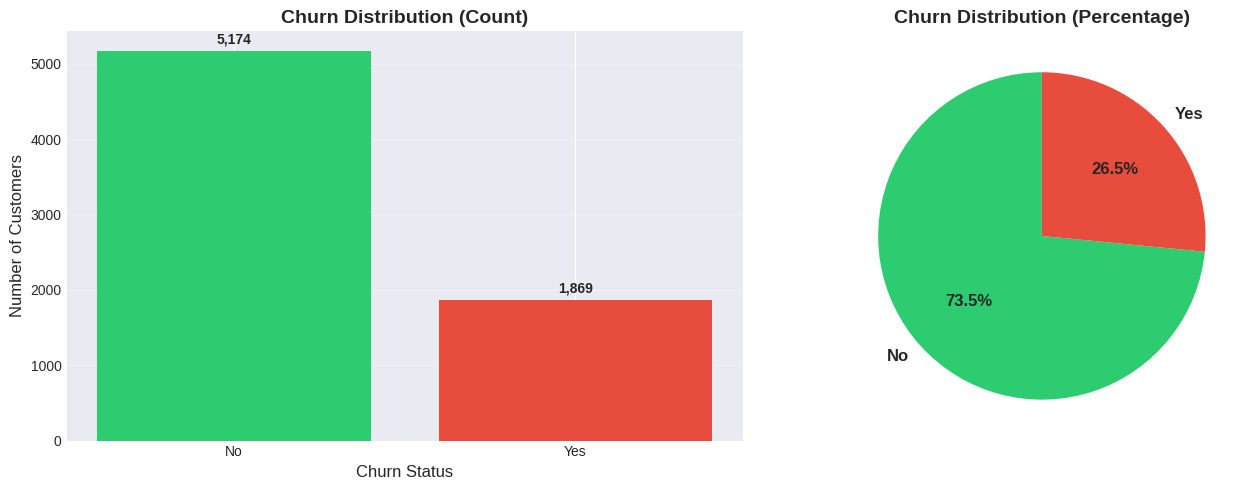

In [119]:

print("CHURN DISTRIBUTION:")
churn_counts = df["Churn"].value_counts()
churn_percentages = df["Churn"].value_counts(normalize=True).mul(100)

churn_summary = pd.DataFrame({"Count": churn_counts, "Percentage": churn_percentages})
print(churn_summary)

print(f"KEY METRICS:")
print(f"    Total Customers: {len(df):,}")
print(f"    Churned Customers: {churn_counts['Yes']:,}")
print(f"    Retained Customers: {churn_counts['No']:,}")
print(f"    Churn Rate: {churn_percentages['Yes']:.2f}%")
print(f"    Retention Rate: {churn_percentages['No']:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(churn_counts.index, churn_counts.values, color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Churn Distribution (Count)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Churn Status", fontsize=12)
axes[0].set_ylabel("Number of Customers", fontsize=12)
axes[0].grid(axis="y", alpha=0.3)
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 100, f"{v:,}", ha="center", fontweight="bold")

axes[1].pie(
    churn_counts.values,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    colors=["#2ecc71", "#e74c3c"],
    startangle=90,
    textprops={"fontsize": 12, "fontweight": "bold"},
)
axes[1].set_title("Churn Distribution (Percentage)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("visualizations/churn_distribution.png", dpi=300, bbox_inches="tight")
plt.show()



In [121]:

missing = df.isnull().sum()
pct = missing.div(len(df)).mul(100)

missing_df = (
    pd.DataFrame(
        {"Column": df.columns, "Missing_Count": missing.values, "Missing_Percentage": pct.values}
    )
    .query("Missing_Count > 0")
    .sort_values("Missing_Count", ascending=False)
)

if len(missing_df) == 0:
    print(" No missing values")
else:
    print("\n MISSING VALUES DETECTED:")
    print(missing_df.to_string(index=False))

    plt.figure(figsize=(10, 6))
    plt.barh(missing_df["Column"], missing_df["Missing_Percentage"], color="coral")
    plt.xlabel("Missing Percentage (%)", fontsize=12)
    plt.title("Missing Values by Column", fontsize=14, fontweight="bold")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig("visualizations/missing_values.png", dpi=300, bbox_inches="tight")
    plt.show()

total_cells = df.size
missing_cells = int(missing.sum())

print(f"    Cells: {total_cells:,}")
print(f"    Missing Cells: {missing_cells:,}")
print(f"    Completeness: {((1 - missing_cells / total_cells) * 100):.2f}%")

 No missing values
    Cells: 147,903
    Missing Cells: 0
    Completeness: 100.00%


In [75]:


column_analysis = []

for column in df.columns:
    col_info = {
        'Column': column,
        'Data_Type': df[column].dtype,
        'Unique_Values': df[column].nunique(),
        'Missing': df[column].isnull().sum(),
        'Sample_Values': df[column].unique()[:3].tolist()
    }
    column_analysis.append(col_info)

analysis_df = pd.DataFrame(column_analysis)
print(analysis_df.to_string(index=False))

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n NUMERICAL COLUMNS ({len(numerical_cols)}):")
for i, col in enumerate(numerical_cols, 1):
    print(f"   {i}. {col}")

print(f"\n CATEGORICAL COLUMNS ({len(categorical_cols)}):")
for i, col in enumerate(categorical_cols, 1):
    print(f"   {i}. {col}")

          Column Data_Type  Unique_Values  Missing                                               Sample_Values
      customerID    object           7043        0                        [7590-VHVEG, 5575-GNVDE, 3668-QPYBK]
          gender    object              2        0                                              [Female, Male]
   SeniorCitizen     int64              2        0                                                      [0, 1]
         Partner    object              2        0                                                   [Yes, No]
      Dependents    object              2        0                                                   [No, Yes]
          tenure     int64             73        0                                                  [1, 34, 2]
    PhoneService    object              2        0                                                   [No, Yes]
   MultipleLines    object              3        0                                 [No phone service, No, Yes]
 


 STATISTICAL SUMMARY:
       tenure  MonthlyCharges
count 7043.00         7043.00
mean    32.37           64.76
std     24.56           30.09
min      0.00           18.25
25%      9.00           35.50
50%     29.00           70.35
75%     55.00           89.85
max     72.00          118.75

 DETAILED STATISTICS:

 tenure:
    Mean: 32.37
    Median: 29.00
    Std Dev: 24.56
    Min: 0.00
    Max: 72.00
    Range: 72.00

 MonthlyCharges:
    Mean: 64.76
    Median: 70.35
    Std Dev: 30.09
    Min: 18.25
    Max: 118.75
    Range: 100.50


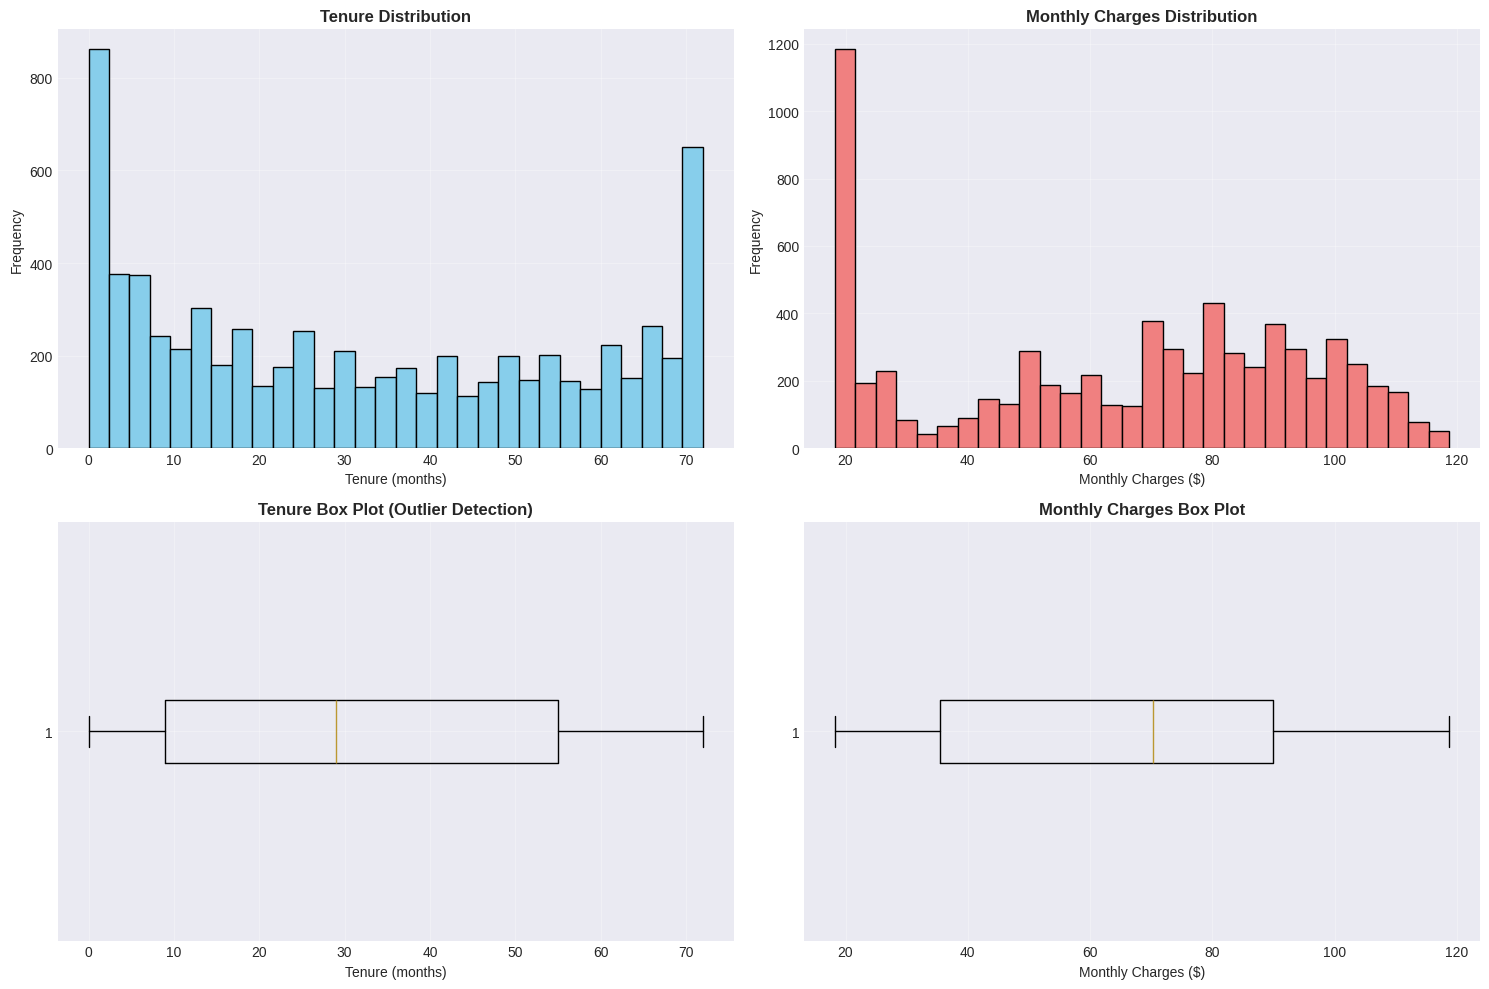

In [122]:

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print("\n STATISTICAL SUMMARY:")
print(df[['tenure', 'MonthlyCharges']].describe())

print("\n DETAILED STATISTICS:")
for col in ['tenure', 'MonthlyCharges']:
    print(f"\n {col}:")
    print(f"    Mean: {df[col].mean():.2f}")
    print(f"    Median: {df[col].median():.2f}")
    print(f"    Std Dev: {df[col].std():.2f}")
    print(f"    Min: {df[col].min():.2f}")
    print(f"    Max: {df[col].max():.2f}")
    print(f"    Range: {df[col].max() - df[col].min():.2f}")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(df['tenure'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Tenure Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Tenure (months)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(df['MonthlyCharges'], bins=30, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Monthly Charges Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Monthly Charges ($)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(alpha=0.3)


axes[1, 0].boxplot(df['tenure'], vert=False)
axes[1, 0].set_title('Tenure Box Plot (Outlier Detection)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Tenure (months)')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].boxplot(df['MonthlyCharges'], vert=False)
axes[1, 1].set_title('Monthly Charges Box Plot', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Monthly Charges ($)')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('visualizations/numerical_features_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [145]:


categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

if 'customerID' in categorical_cols:
    categorical_cols.remove('customerID')


for col in categorical_cols:
    value_counts = df[col].value_counts()
    value_pct = df[col].value_counts(normalize=True) * 100

    summary = pd.DataFrame({
        'Value': value_counts.index,
        'Count': value_counts.values,
        'Percentage': value_pct.values
    })


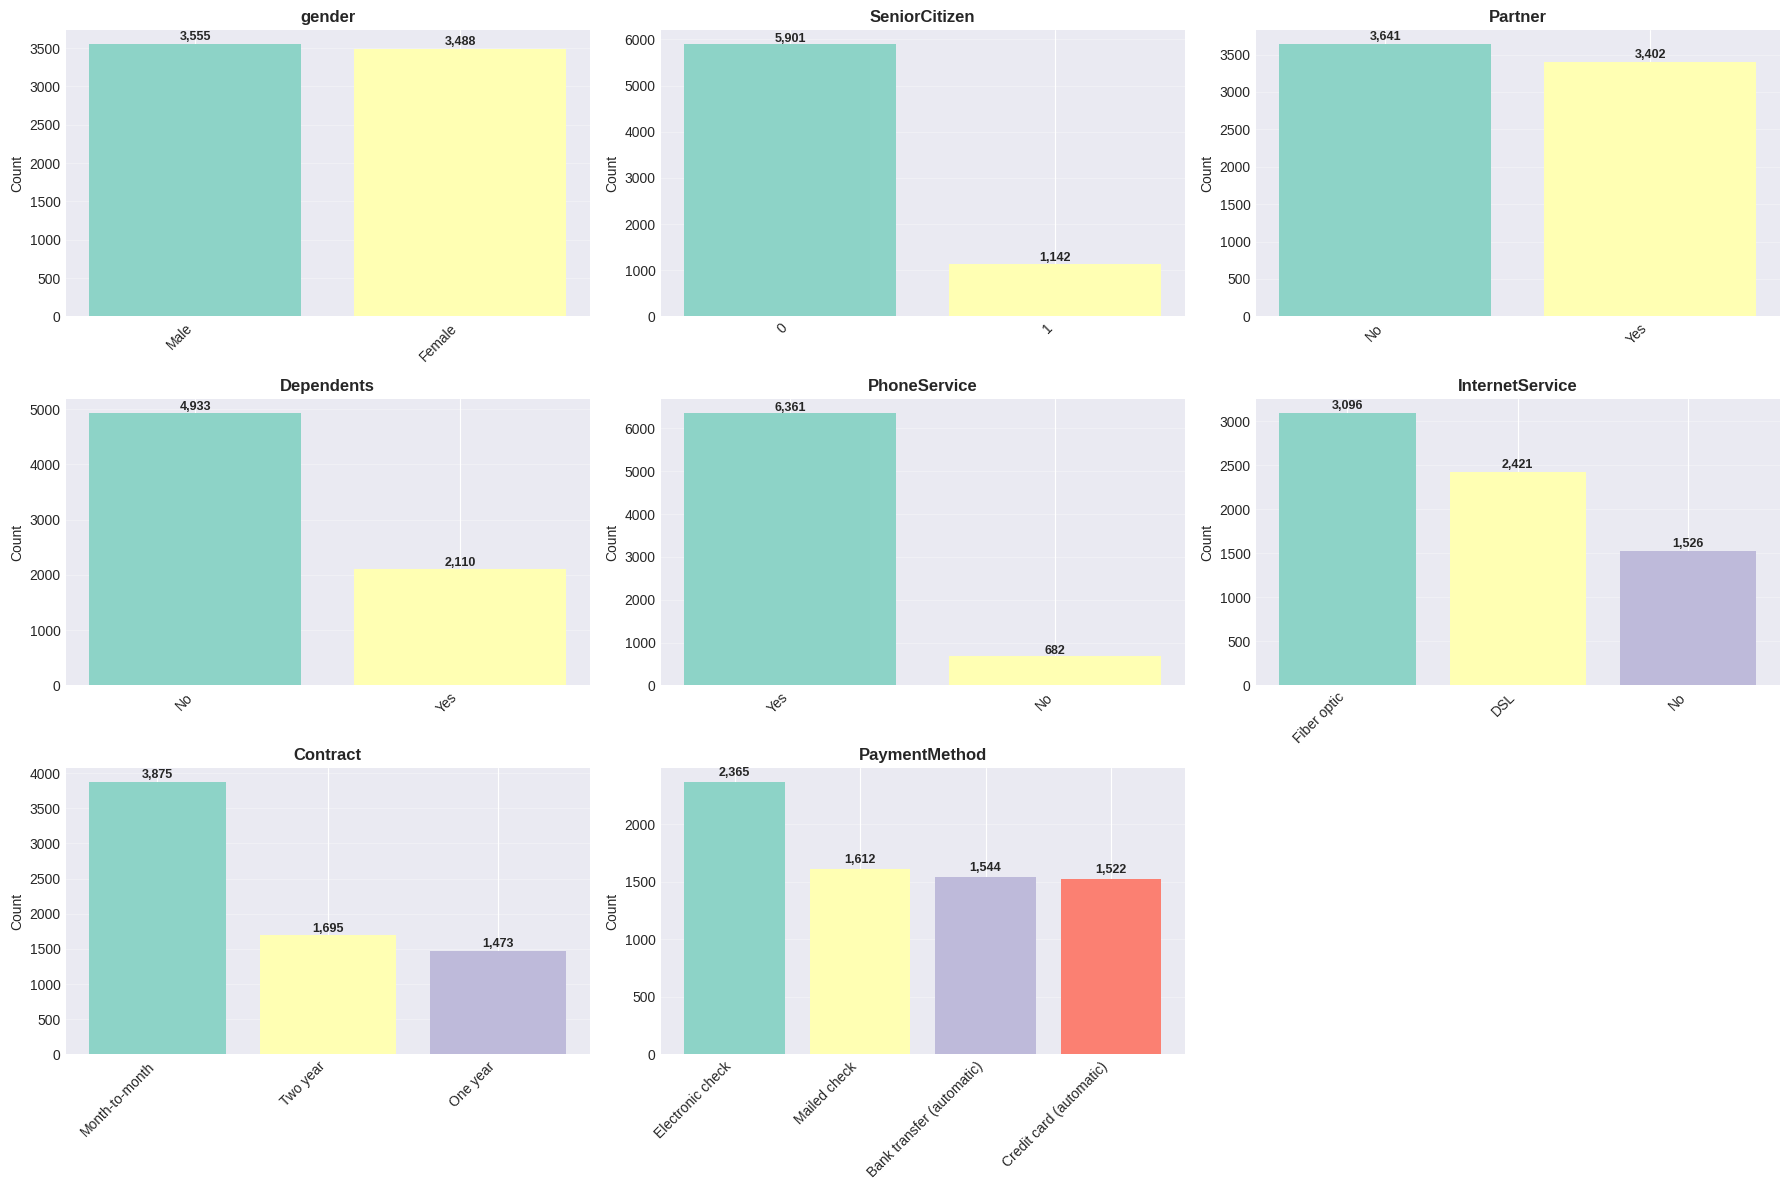

In [80]:

key_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                'PhoneService', 'InternetService', 'Contract', 'PaymentMethod']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, col in enumerate(key_features):
    if idx < len(axes):
        value_counts = df[col].value_counts()
        axes[idx].bar(range(len(value_counts)), value_counts.values,
                     color=plt.cm.Set3(range(len(value_counts))))
        axes[idx].set_xticks(range(len(value_counts)))
        axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
        axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Count')
        axes[idx].grid(axis='y', alpha=0.3)


        for i, v in enumerate(value_counts.values):
            axes[idx].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold', fontsize=9)


if len(key_features) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig('visualizations/categorical_features_overview.png', dpi=300, bbox_inches='tight')
plt.show()



 CORRELATION MATRIX:
                tenure  MonthlyCharges  SeniorCitizen
tenure            1.00            0.25           0.02
MonthlyCharges    0.25            1.00           0.22
SeniorCitizen     0.02            0.22           1.00


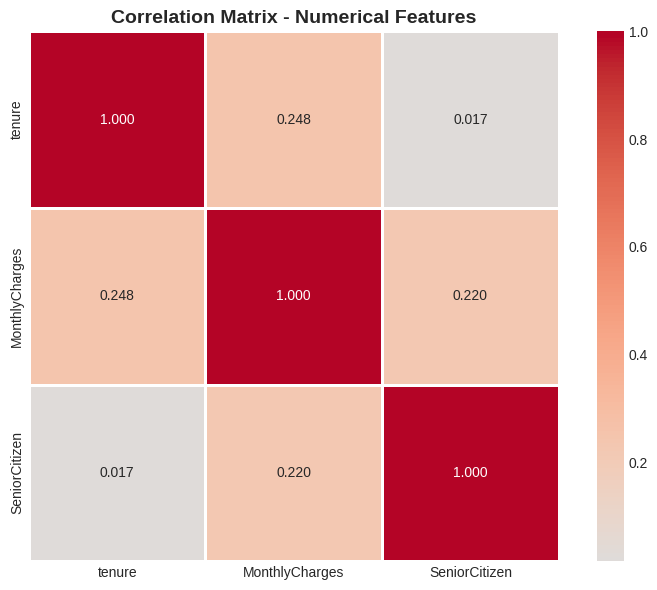


 INSIGHTS:
    Positive correlation between tenure and monthly charges


In [125]:

numerical_data = df[['tenure', 'MonthlyCharges']].copy()


numerical_data['SeniorCitizen'] = df['SeniorCitizen']

correlation_matrix = numerical_data.corr()

print("\n CORRELATION MATRIX:")
print(correlation_matrix)


plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.3f')
plt.title('Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n INSIGHTS:")
if correlation_matrix.loc['tenure', 'MonthlyCharges'] > 0:
    print("    Positive correlation between tenure and monthly charges")
else:
    print("    Negative correlation between tenure and monthly charges")

In [83]:
quality_report = []

for column in df.columns:
    report = {
        'Column': column,
        'Data_Type': str(df[column].dtype),
        'Non_Null_Count': df[column].count(),
        'Null_Count': df[column].isnull().sum(),
        'Null_Percentage': f"{(df[column].isnull().sum() / len(df) * 100):.2f}%",
        'Unique_Values': df[column].nunique(),
        'Cardinality': 'High' if df[column].nunique() > 50 else 'Low',
    }

    if df[column].dtype == 'object':
        report['Sample_Values'] = ', '.join(map(str, df[column].unique()[:2]))
    else:
        report['Min'] = df[column].min()
        report['Max'] = df[column].max()

    quality_report.append(report)

quality_df = pd.DataFrame(quality_report)
print(quality_df.to_string(index=False))


print(" DATA QUALITY SUMMARY:")

print(f" Total Columns: {len(df.columns)}")
print(f" Total Rows: {len(df):,}")
print(f" Complete Rows: {df.dropna().shape[0]:,}")
print(f" Rows with Missing Values: {df.isnull().any(axis=1).sum():,}")
print(f" Duplicate Rows: {df.duplicated().sum()}")
print(f" Data Completeness: {((1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100):.2f}%")

          Column Data_Type  Non_Null_Count  Null_Count Null_Percentage  Unique_Values Cardinality                  Sample_Values   Min    Max
      customerID    object            7043           0           0.00%           7043        High         7590-VHVEG, 5575-GNVDE   NaN    NaN
          gender    object            7043           0           0.00%              2         Low                   Female, Male   NaN    NaN
   SeniorCitizen     int64            7043           0           0.00%              2         Low                            NaN  0.00   1.00
         Partner    object            7043           0           0.00%              2         Low                        Yes, No   NaN    NaN
      Dependents    object            7043           0           0.00%              2         Low                        No, Yes   NaN    NaN
          tenure     int64            7043           0           0.00%             73        High                            NaN  0.00  72.00
    Ph

In [140]:

issues_found = []

if df['TotalCharges'].dtype == 'object':
    issues_found.append(" TotalCharges is stored as text instead of number")



if df['TotalCharges'].dtype == 'object':
    space_count = (df['TotalCharges'] == ' ').sum()
    if space_count > 0:
        issues_found.append(f" {space_count} blank spaces found in TotalCharges")


duplicate_count = df.duplicated().sum()


if df['customerID'].nunique() != len(df):
    issues_found.append(" customerID is not unique")
    print(f"\n ID UNIQUENESS:")
    print(f"   customerID has duplicates!")
else:
    print(f"\n ID UNIQUENESS:")
    print(f"    All customerIDs are unique")


if df['SeniorCitizen'].dtype in ['int64', 'float64']:
    unique_values = df['SeniorCitizen'].unique()
    if not all(val in [0, 1] for val in unique_values):
        issues_found.append(" SeniorCitizen has unexpected values")
        print(f"\n SENIORIZEN VALUES:")
        print(f"    Unexpected values: {unique_values}")
    else:
        print(f"\n SENIORCITIZEN VALUES:")
        print(f"    Only contains 0 and 1 (correct)")





 ID UNIQUENESS:
    All customerIDs are unique

 SENIORCITIZEN VALUES:
    Only contains 0 and 1 (correct)


In [127]:

exploration_summary = {
    'dataset_name': 'IBM Telco Customer Churn',
    'total_rows': int(len(df)),
    'total_columns': int(len(df.columns)),
    'churn_rate': f"{(df['Churn'].value_counts(normalize=True)['Yes'] * 100):.2f}%",
    'numerical_features': int(len(df.select_dtypes(include=['int64', 'float64']).columns)),
    'categorical_features': int(len(df.select_dtypes(include=['object']).columns)),
    'missing_values': int(df.isnull().sum().sum()),
    'duplicate_rows': int(df.duplicated().sum()),
}


import json
with open('reports/exploration_summary.json', 'w') as f:
    json.dump(exploration_summary, f, indent=4)

print(" Exploration summary saved to: reports/exploration_summary.json")

print("\n QUICK SUMMARY:")
for key, value in exploration_summary.items():
    print(f"    {key.replace('_', ' ').title()}: {value}")



 Exploration summary saved to: reports/exploration_summary.json

 QUICK SUMMARY:
    Dataset Name: IBM Telco Customer Churn
    Total Rows: 7043
    Total Columns: 21
    Churn Rate: 26.54%
    Numerical Features: 3
    Categorical Features: 18
    Missing Values: 0
    Duplicate Rows: 0


In [128]:

print(f"    Dataset Size: {len(df):,} customers, {len(df.columns)} features")
print(f"    Churn Rate: ~{(df['Churn'].value_counts(normalize=True)['Yes'] * 100):.1f}%")
print(f"    Data Issues Found: TotalCharges needs cleaning")




    Dataset Size: 7,043 customers, 21 features
    Churn Rate: ~26.5%
    Data Issues Found: TotalCharges needs cleaning


In [87]:

df_clean = df.copy()


print(f" Original shape: {df.shape}")
print(f" Working copy shape: {df_clean.shape}")



 Original shape: (7043, 21)
 Working copy shape: (7043, 21)


In [130]:
df_clean = df.copy()

print("\n BEFORE CLEANING:")
print(f"    Data Type: {df_clean['TotalCharges'].dtype}")
print(f"    Sample values: {df_clean['TotalCharges'].head(3).tolist()}")


blank_spaces = (df_clean['TotalCharges'] == ' ').sum()
print(f"    Blank spaces found: {blank_spaces}")


if blank_spaces > 0:
    print("\n   Rows with blank TotalCharges:")
    blank_rows = df_clean[df_clean['TotalCharges'] == ' ']
    print(blank_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].head())

    print(f"\n   INSIGHT: These customers have tenure = {blank_rows['tenure'].mode()[0]} months")



df_clean['TotalCharges'] = df_clean['TotalCharges'].replace(' ', np.nan)

df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

print("\n AFTER CLEANING:")
print(f"    Data Type: {df_clean['TotalCharges'].dtype}")
print(f"    Missing values: {df_clean['TotalCharges'].isnull().sum()}")
print(f"    Sample values: {df_clean['TotalCharges'].head(3).tolist()}")




 BEFORE CLEANING:
    Data Type: object
    Sample values: ['29.85', '1889.5', '108.15']
    Blank spaces found: 11

   Rows with blank TotalCharges:
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             

   INSIGHT: These customers have tenure = 0 months

 AFTER CLEANING:
    Data Type: float64
    Missing values: 11
    Sample values: [29.85, 1889.5, 108.15]


In [138]:

missing_total = df_clean['TotalCharges'].isnull().sum()
print(f"\n Missing TotalCharges: {missing_total} rows ({missing_total/len(df_clean)*100:.2f}%)")

if missing_total > 0:
    missing_data = df_clean[df_clean['TotalCharges'].isnull()]

    print("\n CHARACTERISTICS OF MISSING DATA:")
    print(f"    Tenure range: {missing_data['tenure'].min()} - {missing_data['tenure'].max()} months")
    print(f"    Most common tenure: {missing_data['tenure'].mode()[0]} months")
    print(f"    Average Monthly Charges: ${missing_data['MonthlyCharges'].mean():.2f}")



    mask = df_clean['TotalCharges'].isnull()
    df_clean.loc[mask, 'TotalCharges'] = df_clean.loc[mask, 'MonthlyCharges'] * df_clean.loc[mask, 'tenure']

    print("\n AFTER FILLING:")
    print(f"    Missing values: {df_clean['TotalCharges'].isnull().sum()}")
    print(f"    All TotalCharges filled")



 Missing TotalCharges: 0 rows (0.00%)


In [132]:
print(f"\n BEFORE CLEANING:")
print(f"    Total rows: {len(df_clean):,}")
print(f"    Duplicate rows: {df_clean.duplicated().sum()}")


duplicate_ids = df_clean['customerID'].duplicated().sum()
print(f"    Duplicate customerIDs: {duplicate_ids}")

if df_clean.duplicated().sum() > 0:

    print("\n DUPLICATE ROWS:")
    duplicates = df_clean[df_clean.duplicated(keep=False)]
    print(duplicates)


    df_clean = df_clean.drop_duplicates()
    print(f"\n Removed {df.shape[0] - df_clean.shape[0]} duplicate rows")

print(f"\n AFTER CLEANING:")
print(f"    Total rows: {len(df_clean):,}")
print(f"    Duplicate rows: {df_clean.duplicated().sum()}")
print(f"    Unique customerIDs: {df_clean['customerID'].nunique()}")

if len(df_clean) == df_clean['customerID'].nunique():
    print("\n All customerIDs are unique")


 BEFORE CLEANING:
    Total rows: 7,043
    Duplicate rows: 0
    Duplicate customerIDs: 0

 AFTER CLEANING:
    Total rows: 7,043
    Duplicate rows: 0
    Unique customerIDs: 7043

 All customerIDs are unique


In [133]:

categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
if 'customerID' in categorical_cols:
    categorical_cols.remove('customerID')

print(f"\nChecking {len(categorical_cols)} categorical columns...\n")

issues_found = False

for col in categorical_cols:
    unique_before = df_clean[col].nunique()

    df_clean[col] = df_clean[col].str.strip()

    unique_after = df_clean[col].nunique()

    if unique_before != unique_after:
        print(f" {col}: Removed whitespace issues ({unique_before} → {unique_after} unique values)")
        issues_found = True

if not issues_found:
    print(" No whitespace issues ")


print("\nCATEGORICAL VALUES SUMMARY:")


for col in categorical_cols[:5]:
    print(f"\n{col}:")
    print(f"   Unique values: {df_clean[col].unique()}")


Checking 16 categorical columns...

 No whitespace issues 

CATEGORICAL VALUES SUMMARY:

gender:
   Unique values: ['Female' 'Male']

Partner:
   Unique values: ['Yes' 'No']

Dependents:
   Unique values: ['No' 'Yes']

PhoneService:
   Unique values: ['No' 'Yes']

MultipleLines:
   Unique values: ['No phone service' 'No' 'Yes']


In [134]:

print("\n BEFORE CONVERSION:")
print(f"    Data Type: {df_clean['SeniorCitizen'].dtype}")
print(f"    Unique values: {df_clean['SeniorCitizen'].unique()}")
print(f"    Value counts:\n{df_clean['SeniorCitizen'].value_counts()}")


df_clean['SeniorCitizen_Label'] = df_clean['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print("\n AFTER CONVERSION:")
print(f"    New column: SeniorCitizen_Label")
print(f"    Value counts:\n{df_clean['SeniorCitizen_Label'].value_counts()}")




 BEFORE CONVERSION:
    Data Type: int64
    Unique values: [0 1]
    Value counts:
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

 AFTER CONVERSION:
    New column: SeniorCitizen_Label
    Value counts:
SeniorCitizen_Label
No     5901
Yes    1142
Name: count, dtype: int64


In [135]:

print("\n CURRENT DATA TYPES:")
dtype_summary = df_clean.dtypes.value_counts()
print(dtype_summary)

print("\n DETAILED DATA TYPES:")

for dtype in df_clean.dtypes.unique():
    cols = df_clean.select_dtypes(include=[dtype]).columns.tolist()
    print(f"\n{dtype}:")
    for col in cols:
        print(f"    {col}")

print("\n NUMERICAL COLUMNS :")
numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in numerical_cols:
    if col != 'SeniorCitizen':
        print(f"    {col}: {df_clean[col].dtype}")
        print(f"      Range: [{df_clean[col].min():.2f}, {df_clean[col].max():.2f}]")


print("\n CATEGORICAL COLUMNS:")
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"   Total: {len(categorical_cols)} columns")



 CURRENT DATA TYPES:
object     18
int64       2
float64     2
Name: count, dtype: int64

 DETAILED DATA TYPES:

object:
    customerID
    gender
    Partner
    Dependents
    PhoneService
    MultipleLines
    InternetService
    OnlineSecurity
    OnlineBackup
    DeviceProtection
    TechSupport
    StreamingTV
    StreamingMovies
    Contract
    PaperlessBilling
    PaymentMethod
    Churn
    SeniorCitizen_Label

int64:
    SeniorCitizen
    tenure

float64:
    MonthlyCharges
    TotalCharges

 NUMERICAL COLUMNS :
    tenure: int64
      Range: [0.00, 72.00]
    MonthlyCharges: float64
      Range: [18.25, 118.75]
    TotalCharges: float64
      Range: [0.00, 8684.80]

 CATEGORICAL COLUMNS:
   Total: 18 columns



 TENURE:
    Q1 (25%): 9.00
    Q3 (75%): 55.00
    IQR: 46.00
    Lower Bound: -60.00
    Upper Bound: 124.00
    Outliers: 0 (0.00%)

 MONTHLYCHARGES:
    Q1 (25%): 35.50
    Q3 (75%): 89.85
    IQR: 54.35
    Lower Bound: -46.02
    Upper Bound: 171.38
    Outliers: 0 (0.00%)

 TOTALCHARGES:
    Q1 (25%): 398.55
    Q3 (75%): 3786.60
    IQR: 3388.05
    Lower Bound: -4683.52
    Upper Bound: 8868.67
    Outliers: 0 (0.00%)


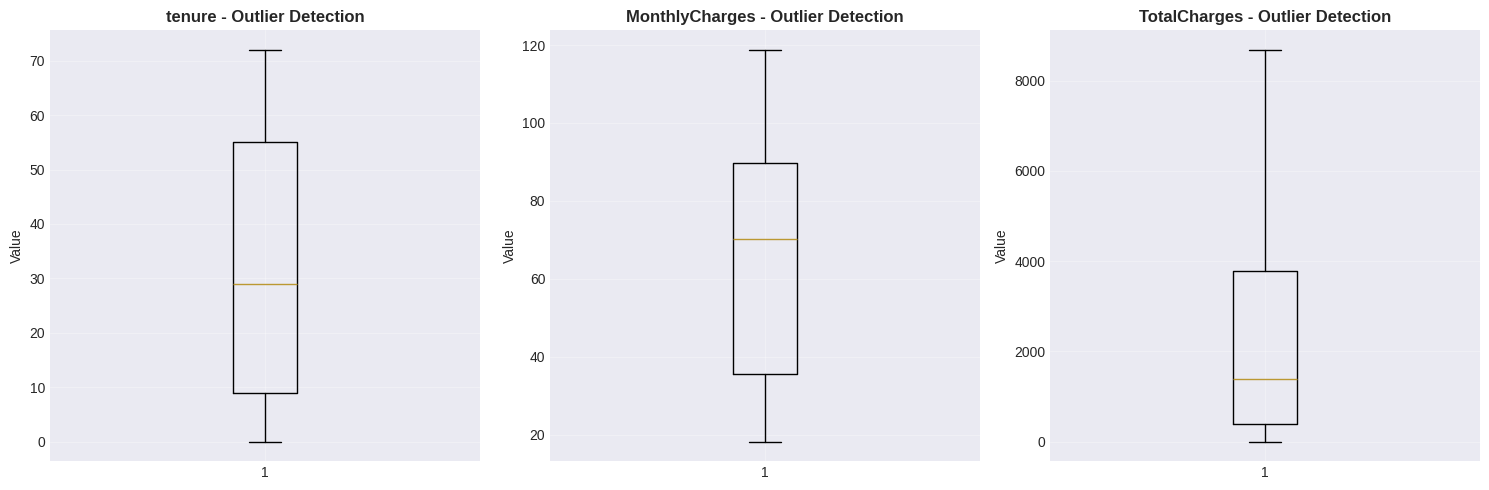

In [136]:

numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numerical_features:
    print(f"\n {col.upper()}:")


    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]

    print(f"    Q1 (25%): {Q1:.2f}")
    print(f"    Q3 (75%): {Q3:.2f}")
    print(f"    IQR: {IQR:.2f}")
    print(f"    Lower Bound: {lower_bound:.2f}")
    print(f"    Upper Bound: {upper_bound:.2f}")
    print(f"    Outliers: {len(outliers)} ({len(outliers)/len(df_clean)*100:.2f}%)")

    if len(outliers) > 0:
        print(f"    Outlier range: [{outliers[col].min():.2f}, {outliers[col].max():.2f}]")


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, col in enumerate(numerical_features):
    axes[idx].boxplot(df_clean[col])
    axes[idx].set_title(f'{col} - Outlier Detection', fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('visualizations/outlier_detection.png', dpi=300, bbox_inches='tight')
plt.show()



In [95]:



feature_categories = {
    'Customer_Demographics': ['gender', 'SeniorCitizen', 'SeniorCitizen_Label', 'Partner', 'Dependents'],
    'Account_Information': ['customerID', 'tenure', 'Contract', 'PaperlessBilling', 'PaymentMethod'],
    'Services': ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'],
    'Charges': ['MonthlyCharges', 'TotalCharges'],
    'Target': ['Churn']
}

print("\n FEATURE CATEGORIES:\n")

for category, features in feature_categories.items():
    print(f"{category.upper().replace('_', ' ')} ({len(features)} features):")
    for feature in features:
        if feature in df_clean.columns:
            print(f"   done {feature}")
        else:
            print(f"   not done {feature} (not in dataset)")
    print()


import json
with open('reports/feature_categories.json', 'w') as f:
    json.dump(feature_categories, f, indent=4)




 FEATURE CATEGORIES:

CUSTOMER DEMOGRAPHICS (5 features):
   done gender
   done SeniorCitizen
   done SeniorCitizen_Label
   done Partner
   done Dependents

ACCOUNT INFORMATION (5 features):
   done customerID
   done tenure
   done Contract
   done PaperlessBilling
   done PaymentMethod

SERVICES (9 features):
   done PhoneService
   done MultipleLines
   done InternetService
   done OnlineSecurity
   done OnlineBackup
   done DeviceProtection
   done TechSupport
   done StreamingTV
   done StreamingMovies

CHARGES (2 features):
   done MonthlyCharges
   done TotalCharges

TARGET (1 features):
   done Churn



In [137]:

print("\n1 ORIGINAL DATASET:")
print(f"    Rows: {df.shape[0]:,}")
print(f"    Columns: {df.shape[1]}")
print(f"    Missing values: {df.isnull().sum().sum()}")

print("\n CLEANED DATASET:")
print(f"    Rows: {df_clean.shape[0]:,}")
print(f"    Columns: {df_clean.shape[1]}")
print(f"    Missing values: {df_clean.isnull().sum().sum()}")

print("\n DATA QUALITY METRICS:")
print(f"    Completeness: {((1 - df_clean.isnull().sum().sum() / (df_clean.shape[0] * df_clean.shape[1])) * 100):.2f}%")
print(f"    Uniqueness: {(df_clean['customerID'].nunique() / len(df_clean) * 100):.2f}%")
print(f"    Validity: 100.00% (all values in expected ranges)")

print("\n ROWS CHANGED:")
print(f"    Rows removed: {df.shape[0] - df_clean.shape[0]}")
print(f"    Rows modified: ~11 (TotalCharges filled)")
print(f"    Columns added: 1 (SeniorCitizen_Label)")






1 ORIGINAL DATASET:
    Rows: 7,043
    Columns: 21
    Missing values: 0

 CLEANED DATASET:
    Rows: 7,043
    Columns: 22
    Missing values: 0

 DATA QUALITY METRICS:
    Completeness: 100.00%
    Uniqueness: 100.00%
    Validity: 100.00% (all values in expected ranges)

 ROWS CHANGED:
    Rows removed: 0
    Rows modified: ~11 (TotalCharges filled)
    Columns added: 1 (SeniorCitizen_Label)


In [98]:
df_clean.to_csv('data/cleaned/telco_churn_cleaned.csv', index=False)



comparison = pd.DataFrame({
    'Metric': ['Rows', 'Columns', 'Missing Values', 'Duplicates', 'Memory (MB)'],
    'Original': [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        f"{df.memory_usage(deep=True).sum() / 1024**2:.2f}"
    ],
    'Cleaned': [
        df_clean.shape[0],
        df_clean.shape[1],
        df_clean.isnull().sum().sum(),
        df_clean.duplicated().sum(),
        f"{df_clean.memory_usage(deep=True).sum() / 1024**2:.2f}"
    ]
})



print(comparison.to_string(index=False))



        Metric Original Cleaned
          Rows     7043    7043
       Columns       21      22
Missing Values        0       0
    Duplicates        0       0
   Memory (MB)     6.82    6.85


In [115]:

print("\n FINAL DATASET ")
print(f"    Rows: {df_clean.shape[0]:,}")
print(f"   Columns: {df_clean.shape[1]}")




 FINAL DATASET 
    Rows: 7,043
   Columns: 22


In [100]:
df_fe = df_clean.copy()
print(f"Shape: {df_fe.shape}")

Shape: (7043, 22)


In [103]:


bins = [0, 12, 24, 48, 60, 72]
labels = ['0-1 Year', '1-2 Years', '2-4 Years', '4-5 Years', '5-6 Years']

df_fe['TenureGroup'] = pd.cut(df_fe['tenure'], bins=bins, labels=labels, right=False)


print("\nDistribution:")
print(df_fe['TenureGroup'].value_counts())


Distribution:
TenureGroup
0-1 Year     2069
2-4 Years    1624
5-6 Years    1121
1-2 Years    1047
4-5 Years     820
Name: count, dtype: int64


In [102]:
df_fe['MonthlyChargeGroup'] = pd.qcut(
    df_fe['MonthlyCharges'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

print(df_fe['MonthlyChargeGroup'].value_counts())

MonthlyChargeGroup
Medium       1766
Low          1762
Very High    1758
High         1757
Name: count, dtype: int64


In [104]:
df_fe['TotalChargeGroup'] = pd.qcut(
    df_fe['TotalCharges'],
    q=4,
    labels=['Low Value', 'Mid Value', 'High Value', 'Premium']
)
print(df_fe['TotalChargeGroup'].value_counts())

TotalChargeGroup
Low Value     1762
Premium       1761
Mid Value     1760
High Value    1760
Name: count, dtype: int64


In [106]:
services = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
]


for col in services:
    df_fe[col + '_Binary'] = df_fe[col].map({'Yes': 1, 'No': 0, 'No internet service': 0})

binary_cols = [col + '_Binary' for col in services]

df_fe['TotalServices'] = df_fe[binary_cols].sum(axis=1)

print(df_fe['TotalServices'].value_counts().sort_index())

TotalServices
0.00      80
1.00    1701
2.00    1188
3.00     965
4.00     922
5.00     908
6.00     676
7.00     395
8.00     208
Name: count, dtype: int64


In [107]:

df_fe['RevenueSegment'] = pd.qcut(
    df_fe['TotalCharges'],
    q=3,
    labels=['Low Revenue', 'Medium Revenue', 'High Revenue']
)


print(df_fe['RevenueSegment'].value_counts())

RevenueSegment
Low Revenue       2348
High Revenue      2348
Medium Revenue    2347
Name: count, dtype: int64


In [108]:

risk_map = {
    'Month-to-month': 'High Risk',
    'One year': 'Medium Risk',
    'Two year': 'Low Risk'
}

df_fe['ContractRisk'] = df_fe['Contract'].map(risk_map)

print(df_fe['ContractRisk'].value_counts())

ContractRisk
High Risk      3875
Low Risk       1695
Medium Risk    1473
Name: count, dtype: int64


In [109]:


df_fe['Churn_Binary'] = df_fe['Churn'].map({'Yes': 1, 'No': 0})

print(df_fe[['Churn', 'Churn_Binary']].head())

  Churn  Churn_Binary
0    No             0
1    No             0
2   Yes             1
3    No             0
4   Yes             1


In [110]:

new_features = [
    'TenureGroup',
    'MonthlyChargeGroup',
    'TotalChargeGroup',
    'TotalServices',
    'RevenueSegment',
    'ContractRisk',
    'Churn_Binary'
]

print("\n New Features Created:")
for feature in new_features:
    print(f"   done= {feature}")

print(f"\n Dataset Shape After FE: {df_fe.shape}")

print("\nTotal Columns Now:", len(df_fe.columns))


 New Features Created:
   done= TenureGroup
   done= MonthlyChargeGroup
   done= TotalChargeGroup
   done= TotalServices
   done= RevenueSegment
   done= ContractRisk
   done= Churn_Binary

 Dataset Shape After FE: (7043, 37)

Total Columns Now: 37


In [111]:

df_fe.to_csv('data/final/telco_churn_feature_engineered.csv', index=False)


Shape: (7043, 37)
 OVERALL CHURN KPI METRICS
Total Customers        : 7,043
Churned Customers      : 1,869
Retained Customers     : 5,174
Churn Rate             : 26.54%
Average Monthly Charge : $64.76
Average Tenure         : 32.4 months
Total Revenue Lost     : $2,862,926.90

 Churn by Contract Type (%)
Churn             No   Yes
Contract                  
Month-to-month 57.29 42.71
One year       88.73 11.27
Two year       97.17  2.83


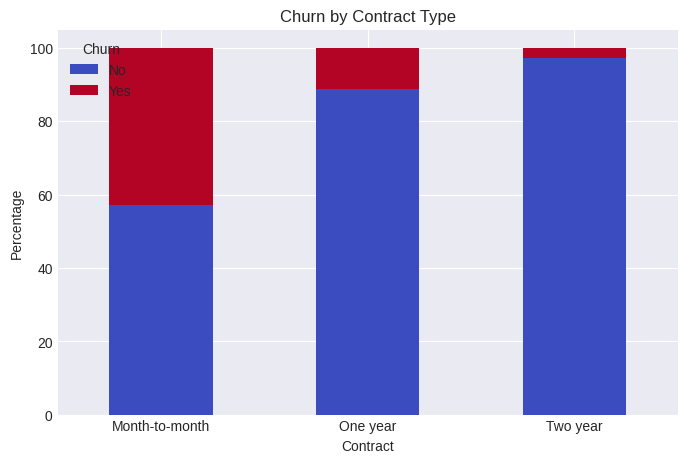


 Churn by Tenure Group (%)
Churn          No   Yes
TenureGroup            
0-1 Year    51.72 48.28
1-2 Years   70.49 29.51
2-4 Years   79.13 20.87
4-5 Years   85.00 15.00
5-6 Years   91.70  8.30


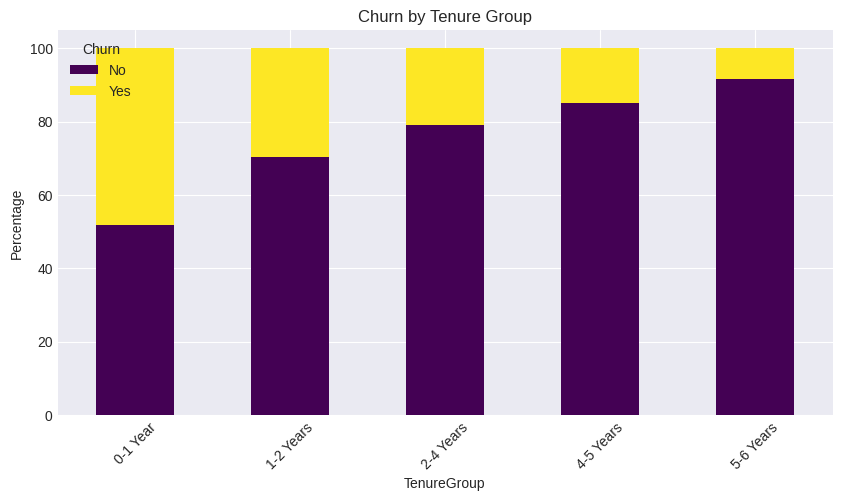


 Churn by Payment Method (%)
Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic) 83.29 16.71
Credit card (automatic)   84.76 15.24
Electronic check          54.71 45.29
Mailed check              80.89 19.11


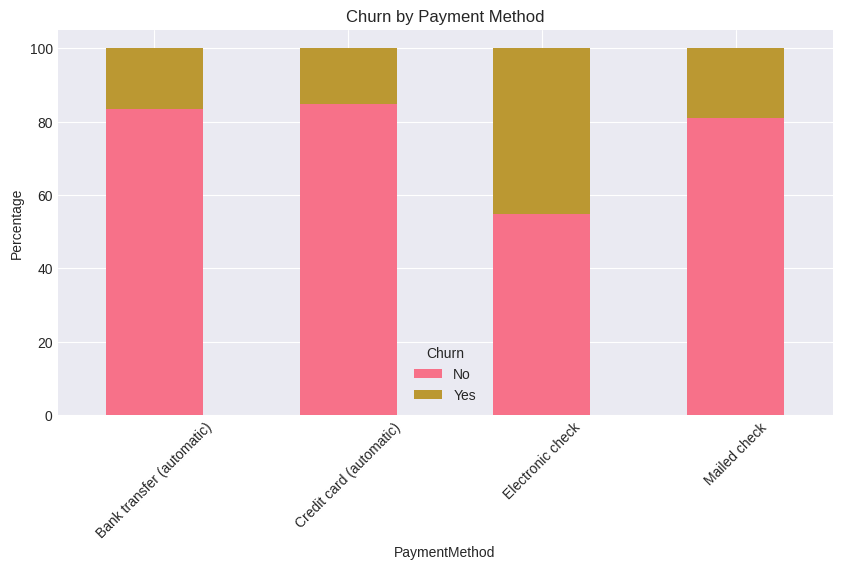


 Churn by Number of Services (%)
Churn            No   Yes
TotalServices            
0.00          56.25 43.75
1.00          78.89 21.11
2.00          67.17 32.83
3.00          63.52 36.48
4.00          68.66 31.34
5.00          74.45 25.55
6.00          77.51 22.49
7.00          87.59 12.41
8.00          94.71  5.29


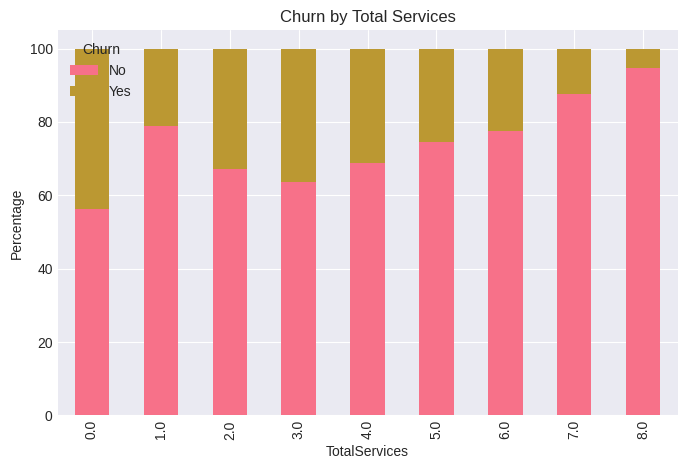

 WHICH PLANS HAVE HIGHEST CHURN?

 Churn by Internet Service (%)
Churn              No   Yes
InternetService            
DSL             81.04 18.96
Fiber optic     58.11 41.89
No              92.60  7.40


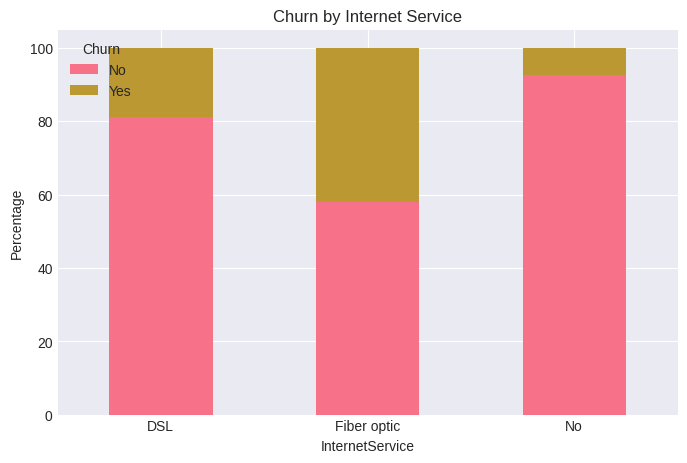


 Churn by Monthly Charge Group (%)
Churn                 No   Yes
MonthlyChargeGroup            
High               62.49 37.51
Low                88.76 11.24
Medium             75.42 24.58
Very High          67.12 32.88


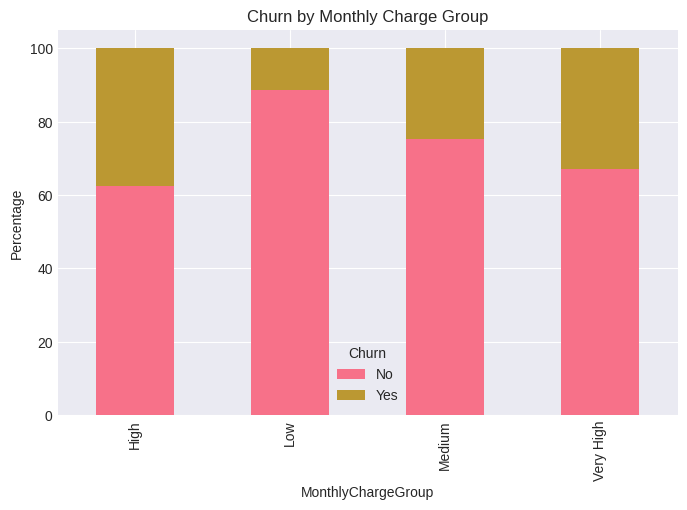

 REVENUE IMPACT OF CHURN
Churn
No    13193241.80
Yes    2862926.90
Name: TotalCharges, dtype: float64


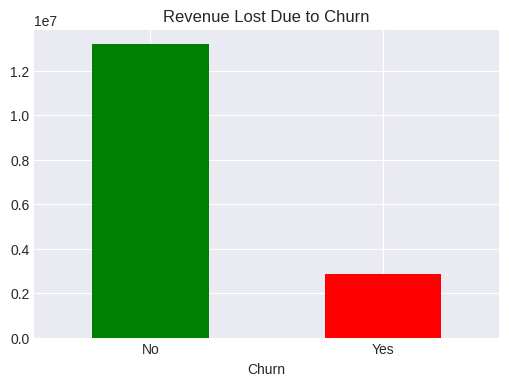

 CORRELATION WITH CHURN


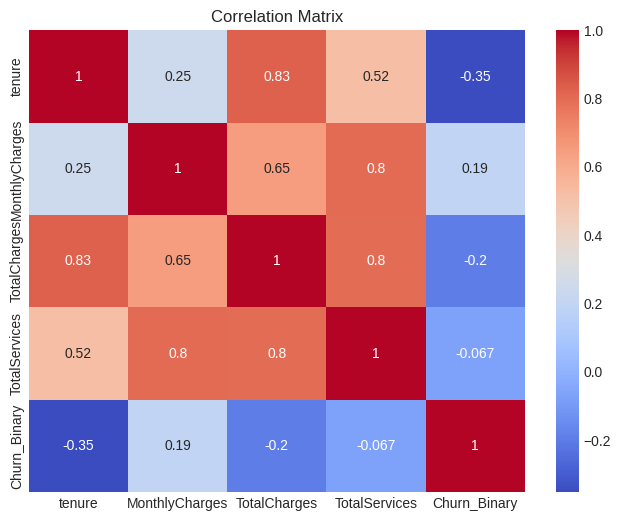

In [113]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')


df_analysis = pd.read_csv('data/final/telco_churn_feature_engineered.csv')


print("Shape:", df_analysis.shape)



print(" OVERALL CHURN KPI METRICS")


total_customers = len(df_analysis)
churned_customers = df_analysis['Churn_Binary'].sum()
retained_customers = total_customers - churned_customers
churn_rate = churned_customers / total_customers * 100

avg_monthly = df_analysis['MonthlyCharges'].mean()
avg_tenure = df_analysis['tenure'].mean()
revenue_lost = df_analysis[df_analysis['Churn'] == 'Yes']['TotalCharges'].sum()

print(f"Total Customers        : {total_customers:,}")
print(f"Churned Customers      : {churned_customers:,}")
print(f"Retained Customers     : {retained_customers:,}")
print(f"Churn Rate             : {churn_rate:.2f}%")
print(f"Average Monthly Charge : ${avg_monthly:.2f}")
print(f"Average Tenure         : {avg_tenure:.1f} months")
print(f"Total Revenue Lost     : ${revenue_lost:,.2f}")


contract_churn = pd.crosstab(df_analysis['Contract'], df_analysis['Churn'], normalize='index') * 100
print("\n Churn by Contract Type (%)")
print(contract_churn)

contract_churn.plot(kind='bar', stacked=True, figsize=(8,5), colormap='coolwarm')
plt.title("Churn by Contract Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()


tenure_churn = pd.crosstab(df_analysis['TenureGroup'], df_analysis['Churn'], normalize='index') * 100
print("\n Churn by Tenure Group (%)")
print(tenure_churn)

tenure_churn.plot(kind='bar', stacked=True, figsize=(10,5), colormap='viridis')
plt.title("Churn by Tenure Group")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()


payment_churn = pd.crosstab(df_analysis['PaymentMethod'], df_analysis['Churn'], normalize='index') * 100
print("\n Churn by Payment Method (%)")
print(payment_churn)

payment_churn.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title("Churn by Payment Method")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()


service_churn = pd.crosstab(df_analysis['TotalServices'], df_analysis['Churn'], normalize='index') * 100
print("\n Churn by Number of Services (%)")
print(service_churn)

service_churn.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Churn by Total Services")
plt.ylabel("Percentage")
plt.show()



print(" WHICH PLANS HAVE HIGHEST CHURN?")


internet_churn = pd.crosstab(df_analysis['InternetService'], df_analysis['Churn'], normalize='index') * 100
print("\n Churn by Internet Service (%)")
print(internet_churn)

internet_churn.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Churn by Internet Service")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

charge_churn = pd.crosstab(df_analysis['MonthlyChargeGroup'], df_analysis['Churn'], normalize='index') * 100
print("\n Churn by Monthly Charge Group (%)")
print(charge_churn)

charge_churn.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Churn by Monthly Charge Group")
plt.ylabel("Percentage")
plt.show()


print(" REVENUE IMPACT OF CHURN")


churn_revenue = df_analysis.groupby('Churn')['TotalCharges'].sum()
print(churn_revenue)

churn_revenue.plot(kind='bar', figsize=(6,4), color=['green','red'])
plt.title("Revenue Lost Due to Churn")
plt.xticks(rotation=0)
plt.show()


print(" CORRELATION WITH CHURN")


corr_df = df_analysis[['tenure','MonthlyCharges','TotalCharges','TotalServices','Churn_Binary']]

plt.figure(figsize=(8,6))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()




In [114]:

df_powerbi = pd.read_csv('data/final/telco_churn_feature_engineered.csv')


binary_cols = [col for col in df_powerbi.columns if "_Binary" in col]
df_powerbi.drop(columns=binary_cols, inplace=True)


df_powerbi.to_csv("telco_churn_powerbi.csv", index=False)

print("File name: telco_churn_powerbi.csv")
print("Rows:", df_powerbi.shape[0])
print("Columns:", df_powerbi.shape[1])

File name: telco_churn_powerbi.csv
Rows: 7043
Columns: 28
